#**1. Fungsi Keanggotaan untuk Klasifikasi Berat**

## A. Pendefinisian Keanggotaan Berat

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Definisikan semesta pembicaraan untuk berat (0 hingga 1 kg)
x_weight = np.arange(0, 1.01, 0.01)

# Definisikan fungsi keanggotaan untuk 'ringan' (segitiga)
a_ringan, b_ringan, c_ringan = 0, 0.25, 0.5

# Definisikan fungsi keanggotaan untuk 'sedang' (segitiga)
a_sedang, b_sedang, c_sedang = 0.2, 0.5, 0.8

# Definisikan fungsi keanggotaan untuk 'berat' (segitiga)
a_berat, b_berat, c_berat = 0.5, 0.75, 1

## B. Pembuatan variabel secara terpisah

In [29]:
xp_ringan = [a_ringan, b_ringan, c_ringan]
fp_ringan = [0, 1, 0]
weight_ringan = np.interp(x_weight, xp_ringan, fp_ringan)

xp_sedang = [a_sedang, b_sedang, c_sedang]
fp_sedang = [0, 1, 0]
weight_sedang = np.interp(x_weight, xp_sedang, fp_sedang)

xp_berat = [a_berat, b_berat, c_berat]
fp_berat = [0, 1, 0]
weight_berat = np.interp(x_weight, xp_berat, fp_berat)

#**2. Fungsi Keanggotaan untuk Klasifikasi Gerak Servo**

## A. Pendefinisian Keanggotaan Gerak **Servo**

In [ ]:
# Rentang semesta untuk arah motor servo (0 hingga 180 derajat)
x_motor_direction = np.arange(0, 180.1, 0.1)

# Faktor skala dari rentang berat (0-1) ke rentang derajat servo (0-180)
scaling_factor = 180

## B. Pembuatan variabel setiap kategori

In [ ]:
# Definisikan fungsi keanggotaan untuk 'kiri' (segitiga)
# Parameter a_ringan, b_ringan, c_ringan diasumsikan sudah ada dari cell sebelumnya
a_kiri = a_ringan * scaling_factor
b_kiri = b_ringan * scaling_factor
c_kiri = c_ringan * scaling_factor

xp_kiri = [a_kiri, b_kiri, c_kiri]
fp_kiri = [0, 1, 0]
motor_kiri_mf = np.interp(x_motor_direction, xp_kiri, fp_kiri)

# Definisikan fungsi keanggotaan untuk 'tengah' (segitiga)
# Parameter a_sedang, b_sedang, c_sedang diasumsikan sudah ada dari cell sebelumnya
a_tengah = a_sedang * scaling_factor
b_tengah = b_sedang * scaling_factor
c_tengah = c_sedang * scaling_factor

xp_tengah = [a_tengah, b_tengah, c_tengah]
fp_tengah = [0, 1, 0]
motor_tengah_mf = np.interp(x_motor_direction, xp_tengah, fp_tengah)

# Definisikan fungsi keanggotaan untuk 'kanan' (segitiga)
# Parameter a_berat, b_berat, c_berat diasumsikan sudah ada dari cell sebelumnya
a_kanan = a_berat * scaling_factor
b_kanan = b_berat * scaling_factor
c_kanan = c_berat * scaling_factor

xp_kanan = [a_kanan, b_kanan, c_kanan]
fp_kanan = [0, 1, 0]
motor_kanan_mf = np.interp(x_motor_direction, xp_kanan, fp_kanan)

# **3. Plot Grafik Fungsi Keanggotaan**

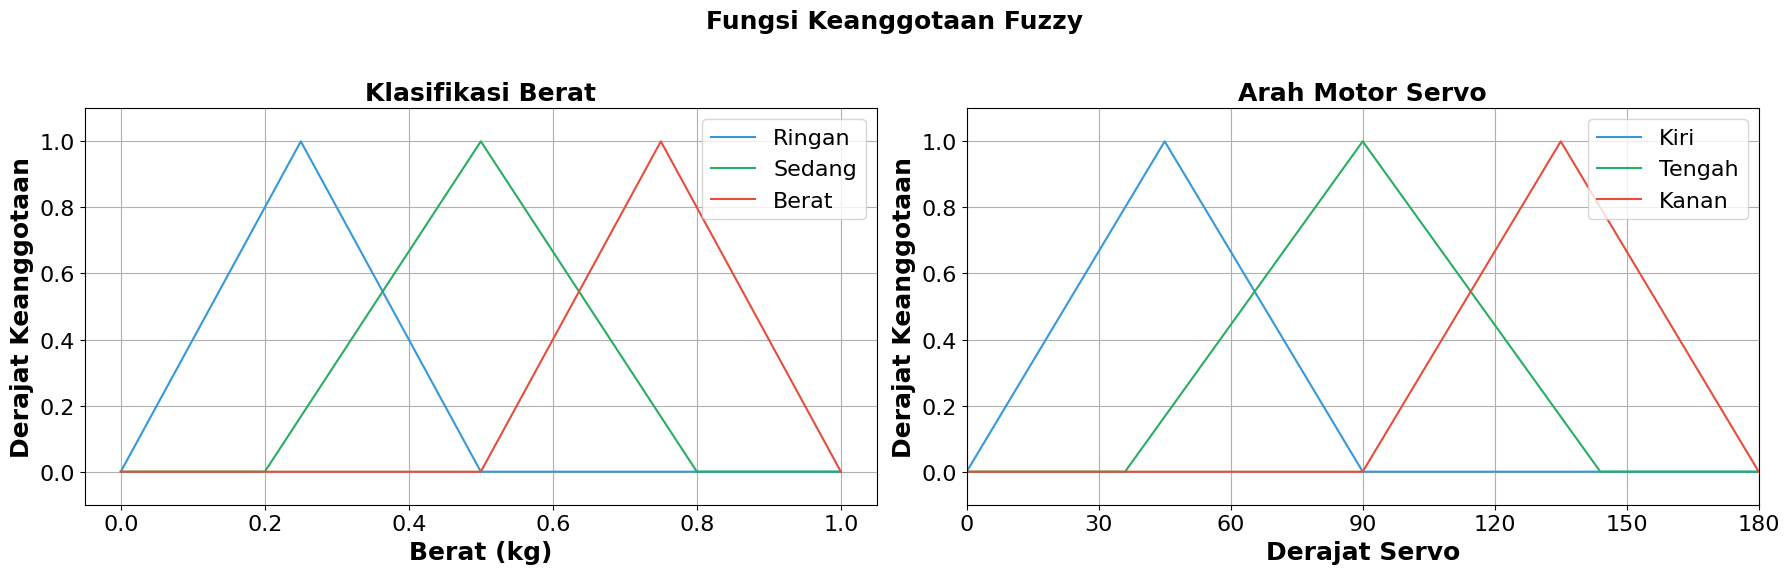

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- Customisasi Tampilan --- (Anda bisa ubah nilai-nilai di sini)
title_fontsize = 18
title_fontweight = 'bold'
label_fontsize = 18
label_fontweight = 'bold'
legend_fontsize = 16
tick_labelsize = 16

# Buat satu figure dengan dua subplot (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Ukuran figure disesuaikan
fig.suptitle('Fungsi Keanggotaan Fuzzy', fontsize=title_fontsize, fontweight=title_fontweight)

# --- Subplot 1: Fungsi Keanggotaan Berat ---
ax1 = axes[0]
ax1.plot(x_weight, weight_ringan, label='Ringan', color='#3498DB')
ax1.plot(x_weight, weight_sedang, label='Sedang', color='#27AE60')
ax1.plot(x_weight, weight_berat, label='Berat', color='#E74C3C')

ax1.set_title('Klasifikasi Berat', fontsize=title_fontsize, fontweight=title_fontweight)
ax1.set_xlabel('Berat (kg)', fontsize=label_fontsize, fontweight=label_fontweight)
ax1.set_ylabel('Derajat Keanggotaan', fontsize=label_fontsize, fontweight=label_fontweight)
ax1.set_ylim(-0.1, 1.1)
ax1.legend(fontsize=legend_fontsize)
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=tick_labelsize)

# --- Subplot 2: Fungsi Keanggotaan Motor Servo ---
ax2 = axes[1]
ax2.plot(x_motor_direction, motor_kiri_mf, label='Kiri', color='#3498DB')
ax2.plot(x_motor_direction, motor_tengah_mf, label='Tengah', color='#27AE60')
ax2.plot(x_motor_direction, motor_kanan_mf, label='Kanan', color='#E74C3C')

ax2.set_title('Arah Motor Servo', fontsize=title_fontsize, fontweight=title_fontweight)
ax2.set_xlabel('Derajat Servo', fontsize=label_fontsize, fontweight=label_fontweight)
ax2.set_ylabel('Derajat Keanggotaan', fontsize=label_fontsize, fontweight=label_fontweight)
ax2.set_ylim(-0.1, 1.1)
ax2.set_xlim(0, 180) # Set x-axis limit from 0 to 180
ax2.set_xticks(np.arange(0, 181, 30)) # Set x-ticks every 30 degrees for clarity
ax2.legend(fontsize=legend_fontsize)
ax2.grid(True)
ax2.tick_params(axis='both', which='major', labelsize=tick_labelsize)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Menyesuaikan layout agar judul tidak tumpang tindih
plt.show()

# **4. Sistem Inferensi Fuzzy (Fuzzifikasi dan Agregasi)**

In [15]:
def fuzzifikasi(input_val, universe, mf_list):
    """Menghitung derajat keanggotaan input untuk setiap fungsi keanggotaan."""
    return [np.interp(input_val, universe, mf) for mf in mf_list]

def apply_rule(antecedent_degree, consequent_mf):
    """Menerapkan implikasi (min) untuk mendapatkan fungsi keanggotaan output."""
    return np.fmin(antecedent_degree, consequent_mf)

def aggregasi(consequent_mfs_hasil):
    """Menggabungkan semua fungsi keanggotaan output menjadi satu (max)."""
    return np.fmax.reduce(consequent_mfs_hasil)

# 4. Definisikan Aturan Fuzzy secara konseptual
# Rule 1: IF berat IS ringan THEN arah_motor IS kiri
# Rule 2: IF berat IS sedang THEN arah_motor IS diam
# Rule 3: IF berat IS berat THEN arah_motor IS kanan

## A. Setup Membership Function

In [ ]:
x_weight        = np.arange(0, 1.01, 0.01)
weight_mfs      = [weight_ringan, weight_sedang, weight_berat]
weight_labels   = ['Ringan', 'Sedang', 'Berat']
weight_colors   = ['#3498DB', '#27AE60', '#E74C3C']

# Pasangan rule: index MF berat → index MF BERAT
rules = [(0, 0), (1, 1), (2, 2)]
rule1_texts = [
    'Rule 1: IF berat IS Ringan  → RINGAN',
    'Rule 2: IF berat IS Sedang  → SEDANG',
    'Rule 3: IF berat IS Berat   → BERAT',
]

In [ ]:
x_motor  = x_motor_direction
motor_mfs     = [motor_kiri_mf, motor_tengah_mf, motor_kanan_mf]
motor_labels  = ['Kiri', 'Tengah', 'Kanan']
motor_colors  = ['#3498DB', '#27AE60', '#E74C3C']

rules = [(0, 0), (1, 1), (2, 2)]
rule_texts = [
    'Rule 1: IF berat IS Ringan  → MOTOR SERVO KIRI',
    'Rule 2: IF berat IS Sedang  → MOTOR SERVO TENGAH',
    'Rule 3: IF berat IS Berat   → MOTOR SERVO KANAN',
]

## B. Fungsi Plot Utama Berat
*   Plot 1   : Fuzzifikasi
*   Plot 2-4 : Clipping Per Rule
*   Plot 5   : Agregasi MAX

In [16]:
import ipywidgets as widgets
from IPython.display import display

# --- Fungsi plot utama ---
def plot_inferensi(berat):
    # Hitung firing strength tiap rule
    fs = [np.interp(berat, x_weight, weight_mfs[i]) for i, _ in rules]

    n_plots = 1 + len(rules) + 1          # fuzzifikasi + per-rule + agregasi
    fig, axes = plt.subplots(n_plots, 1, figsize=(9, 4 * n_plots))
    fig.suptitle(f'Inferensi Fuzzy — Input Berat: {berat:.2f} kg',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── Plot 1: Fuzzifikasi ────────────────────────────────
    ax = axes[0]
    for mf, label, color in zip(weight_mfs, weight_labels, weight_colors):
        ax.plot(x_weight, mf, color=color, linewidth=2, label=label)
        ax.fill_between(x_weight, mf, alpha=0.08, color=color)

    ax.axvline(berat, color='black', linewidth=2, linestyle='--', label=f'Input = {berat:.2f} kg')

    # Tandai titik potong setiap MF
    for mf, color, f in zip(weight_mfs, weight_colors, fs):
        if f > 0:
            ax.plot(berat, f, 'o', color=color, markersize=8, zorder=5)
            ax.annotate(f'  µ={f:.3f}', xy=(berat, f),
                        fontsize=9, color=color, va='center')

    ax.set_title('Langkah 1 — Fuzzifikasi Input', fontweight='bold')
    ax.set_xlabel('Berat (kg)')
    ax.set_ylabel('Derajat Keanggotaan µ')
    ax.set_ylim(-0.1, 1.15)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.4)

    # ── Plot 2–4: Per Rule (Clipping) ────────────────────
    for idx, ((wi, mi), rule_text, f) in enumerate(zip(rules, rule1_texts, fs)):
        ax = axes[1 + idx]
        weight_mf   = weight_mfs[mi]
        weight_color = weight_colors[mi]

        # MF output asli (tipis)
        ax.plot(x_weight, weight_mf, color=weight_color,linewidth=1.5, linestyle='--', alpha=0.4, label='MF output asli')

        # Clipping: potong MF di firing strength
        clipped = np.fmin(f, weight_mf)
        ax.fill_between(x_weight, clipped, alpha=0.35, color=weight_color, label=f'Clipped (α={f:.3f})')
        ax.plot(x_weight, clipped, color=weight_color, linewidth=2)

        # Garis firing strength
        ax.axhline(f, color='black', linewidth=1.2, linestyle=':', alpha=0.7,label=f'Firing strength = {f:.3f}')

        status = 'AKTIF' if f > 0 else 'TIDAK AKTIF'
        color_status = '#27AE60' if f > 0 else '#E74C3C'
        ax.set_title(f'Langkah 2 — {rule_text}  [{status}]',fontweight='bold', color=color_status)
        ax.set_xlabel('Berat (kg)')
        ax.set_ylabel('Derajat Keanggotaan µ')
        ax.set_ylim(-0.1, 1.15)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.4)

    # ── Plot 5: Agregasi MAX ──────────────────────────────
    ax = axes[-1]

    # Kumpulkan semua clipped MF
    clipped_all = [np.fmin(fs[i], weight_mfs[mi]) for i, (wi, mi) in enumerate(rules)]

    # Agregasi dengan MAX
    agregat = np.fmax.reduce(clipped_all)

    # Plot tiap kontribusi (transparan) dan MF output asli
    for i, (wi, mi) in enumerate(rules):
        clipped = clipped_all[i]
        original_mf = weight_mfs[mi]
        color = weight_colors[mi]
        label = weight_labels[mi]

        ax.fill_between(x_weight, clipped, alpha=0.2, color=color)
        ax.plot(x_weight, clipped, color=color, linewidth=1.2, linestyle='--', alpha=0.6, label=f'Kontribusi {label}')

        # Plot MF output asli (tipis)
        ax.plot(x_weight, original_mf, color=color, linewidth=1, linestyle=':', alpha=0.5, label=f'MF {label} Asli')

    # Plot hasil agregasi
    ax.fill_between(x_weight, agregat, alpha=0.4, color='purple')
    ax.plot(x_weight, agregat, color='purple', linewidth=2.5, label='Agregasi MAX')

    ax.set_title('Langkah 3 — Agregasi (Operator MAX)', fontweight='bold')
    ax.set_xlabel('Berat (kg)')
    ax.set_ylabel('Derajat Keanggotaan µ')
    ax.set_ylim(-0.1, 1.15)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- Widget Slider ---
slider = widgets.FloatSlider(value=0.35,min=0.0,max=1.0,step=0.01,description='Berat (kg):',continuous_update=True,style={'description_width': '90px'},layout=widgets.Layout(width='500px'))

## C. Fungsi Plot Utama Servo
*   Plot 1   : Fuzzifikasi
*   Plot 2-4 : Clipping Per Rule
*   Plot 5   : Agregasi MAX

In [17]:
def plot_servo_inference(berat):
    # FIRING STRENGTH
    fs = [np.interp(berat, x_weight, weight_mfs[i])  for i, _ in rules]

    # FIGURE
    n_plots = 1 + len(rules) + 1
    fig, axes = plt.subplots(n_plots,1,figsize=(10, 4 * n_plots))
    fig.suptitle(f'Inferensi Fuzzy — Input Berat: {berat:.2f} kg', fontsize=14, fontweight='bold', y=1.01)

    # LANGKAH 1 — FUZZIFIKASI
    ax = axes[0]
    for mf, label, color in zip(weight_mfs,weight_labels,weight_colors):
        ax.plot(x_weight,mf,color=color,linewidth=2,label=label)
        ax.fill_between(x_weight,mf,alpha=0.08,color=color)

    ax.axvline(berat,color='black',linestyle='--',linewidth=2,label=f'Input = {berat:.2f} kg')

    # titik potong
    for mf, color, f in zip(weight_mfs,weight_colors, fs):
        if f > 0:
            ax.plot(berat,f,'o',color=color,markersize=8)
            ax.annotate(f'μ={f:.3f}',xy=(berat, f),fontsize=9)

    ax.set_title('Langkah 1 — Fuzzifikasi')
    ax.set_xlabel('Berat (kg)')
    ax.set_ylabel('μ')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True)
    ax.legend()

    # LANGKAH 2 — RULE EVALUATION
    clipped_all = []

    for idx, ((wi, mi), rule_text, f) in enumerate(zip(rules, rule_texts, fs)):
        ax = axes[1 + idx]
        motor_mf = motor_mfs[mi]
        color    = motor_colors[mi]
        clipped = np.fmin(f, motor_mf)
        clipped_all.append(clipped)
        # MF asli
        ax.plot(x_motor,motor_mf,linestyle='--',color=color,linewidth=1.5,alpha=0.4,label='MF Output')

        # clipping
        ax.fill_between(x_motor,clipped,alpha=0.35,color=color,label=f'α = {f:.3f}')
        ax.plot(x_motor,clipped,color=color,linewidth=2)
        ax.axhline(f,color='black',linestyle=':',linewidth=1.2)

        status = 'AKTIF' if f > 0 else 'TIDAK AKTIF'
        ax.set_title(f'{rule_text} [{status}]')
        ax.set_xlim(0, 180)
        ax.set_ylim(-0.1, 1.1)
        ax.set_xticks(np.arange(0, 181, 15))
        ax.set_xlabel('Sudut Servo')
        ax.set_ylabel('μ')
        ax.grid(True)
        ax.legend()

    # LANGKAH 3 — AGREGASI MAX
    ax = axes[-1]
    agregat = np.fmax.reduce(clipped_all)
    for clipped, color, label in zip(clipped_all,motor_colors,motor_labels):
        ax.fill_between(x_motor,clipped,alpha=0.15,color=color)
        ax.plot(x_motor,clipped,linestyle='--',linewidth=1,color=color,label=f'Kontribusi {label}')

    ax.fill_between(x_motor,agregat,alpha=0.4,color='purple')
    ax.plot(x_motor,agregat,color='purple',linewidth=2.5,label='Agregasi MAX')
    ax.set_title('Langkah 3 — Agregasi MAX')
    ax.set_xlim(0, 180)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks(np.arange(0, 181, 15))
    ax.set_xlabel('Sudut Servo')
    ax.set_ylabel('μ')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

## D. Plot Grafik

In [18]:

output = widgets.interactive_output(plot_inferensi, {'berat': slider})
display(slider, output)

FloatSlider(value=0.35, description='Berat (kg):', layout=Layout(width='500px'), max=1.0, step=0.01, style=Sli…

Output()

Output()

In [ ]:
output = widgets.interactive_output(plot_servo_inference,{'berat': slider})
display(output)

# **5. DEFUZZIFIKASI KATEGORI BERAT**

## A. Fungsi Defuzzifikasi CoG dan Sugeno

In [19]:
def defuzzifikasi_cog(x, aggregated_mf):
    # Pastikan aggregated_mf dan x memiliki ukuran yang sama
    if len(x) != len(aggregated_mf):
        raise ValueError("Ukuran x dan aggregated_mf harus sama.")

    # Hitung CoG menggunakan formula: sum(x * mu(x)) / sum(mu(x))
    numerator = np.sum(x * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        return 0.0 # Jika tidak ada firing strength, output 0
    else:
        return numerator / denominator

In [20]:
# --- Defuzzifikasi Sugeno (Weighted Average) ---
def defuzzifikasi_sugeno(firing_strengths, consequent_values):
    """Menghitung output crisp menggunakan metode Sugeno (Weighted Average).
    Args:
        firing_strengths (list/array): Derajat keanggotaan (firing strength) dari setiap rule.
        consequent_values (list/array): Nilai crisp output (z-values) untuk setiap rule.

    Returns:
        float: Output crisp hasil defuzzifikasi Sugeno.
    """
    if len(firing_strengths) != len(consequent_values):
        raise ValueError("Panjang firing_strengths dan consequent_values harus sama.")

    numerator = np.sum(np.array(firing_strengths) * np.array(consequent_values))
    denominator = np.sum(firing_strengths)

    if denominator == 0:
        return 0.0 # Jika tidak ada firing strength, output 0
    else:
        return numerator / denominator

## B. Kalkulasi Defuzzifikasi Berat Menggunakan CoG

In [38]:
def process_berat_and_classify_cog(berat):
    print(f"--- Pemrosesan Berat Input: {berat:.2f} kg ---")

    # 1. Fuzzifikasi: Hitung derajat keanggotaan input 'berat' di setiap MF berat
    fs_weights = [np.interp(berat, x_weight, mf) for mf in weight_mfs]
    print(f"\nDerajat Keanggotaan (Firing Strengths) untuk Berat {berat:.2f} kg:")
    for label, f in zip(weight_labels, fs_weights):
        print(f"  μ({label}) = {f:.3f}")

    # 2. Aplikasi Aturan (implikasi) dan Agregasi untuk variabel 'berat' itu sendiri
    #    Ini membentuk MF agregat seolah-olah 'berat' adalah variabel output
    clipped_mfs = [np.fmin(fs_weights[i], weight_mfs[i]) for i in range(len(weight_mfs))]
    agregat_berat_mf = np.fmax.reduce(clipped_mfs)
    print(f"\nAgregasi: Fungsi Keanggotaan Gabungan untuk Berat telah terbentuk.")

    # 3. Defuzzifikasi menggunakan CoG pada agregat_berat_mf
    cog_berat_output = defuzzifikasi_cog(x_weight, agregat_berat_mf)

    print(f"\n--- Kalkulasi Center of Gravity untuk Variabel Berat ---\n")
    print(f"CoG = Σ(x * μ(x)) / Σ(μ(x))")
    print(f"  di mana:")
    print(f"    x    = nilai pada sumbu X (Berat)")
    print(f"    μ(x) = derajat keanggotaan pada titik x (dari fungsi keanggotaan agregasi)")

    # Detailed calculation for Numerator
    numerator_terms_array = x_weight * agregat_berat_mf
    print(f"\n  Langkah-langkah Numerator (Σ(x * μ(x))):")
    print("  Menjumlahkan produk dari setiap nilai 'x' (berat) dengan 'μ(x)' (derajat keanggotaan agregasi) pada titik tersebut.")
    print("  Beberapa istilah (x * μ(x)) yang dijumlahkan:")
    # Print first few terms
    for i in range(min(3, len(x_weight))):
        print(f"    ({x_weight[i]:.2f} * {agregat_berat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")
    if len(x_weight) > 6: # More than 3 start + 3 end terms
        print("    ...")
        for i in range(len(x_weight) - 3, len(x_weight)):
            print(f"    ({x_weight[i]:.2f} * {agregat_berat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")
    elif len(x_weight) > 3:
         for i in range(3, len(x_weight)):
            print(f"    ({x_weight[i]:.2f} * {agregat_berat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")

    numerator_sum = np.sum(numerator_terms_array)
    print(f"  Total Numerator (Σ(x * μ(x))) = {numerator_sum:.2f}")

    # Detailed calculation for Denominator
    denominator_terms_array = agregat_berat_mf
    print(f"\n  Langkah-langkah Denominator (Σ(μ(x))):")
    print("  Menjumlahkan semua nilai 'μ(x)' (derajat keanggotaan agregasi) pada setiap titik 'x'.")
    print("  Beberapa istilah (μ(x)) yang dijumlahkan:")
    # Print first few terms
    for i in range(min(3, len(x_weight))):
        print(f"    μ(x[{i}]) = {agregat_berat_mf[i]:.4f}")
    if len(x_weight) > 6:
        print("    ...")
        for i in range(len(x_weight) - 3, len(x_weight)):
            print(f"    μ(x[{i}]) = {agregat_berat_mf[i]:.4f}")
    elif len(x_weight) > 3:
        for i in range(3, len(x_weight)):
            print(f"    μ(x[{i}]) = {agregat_berat_mf[i]:.4f}")

    denominator_sum = np.sum(denominator_terms_array)
    print(f"  Total Denominator (Σ(μ(x))) = {denominator_sum:.2f}")

    print(f"\n  CoG = Numerator / Denominator = {numerator_sum:.2f} / {denominator_sum:.2f} = {cog_berat_output:.2f}")
    print(f"Hasil Defuzzifikasi CoG untuk Berat: {cog_berat_output:.2f} kg")


    # 4. Klasifikasi Akhir: Tentukan kategori 'berat' berdasarkan hasil CoG
    membership_at_cog = [np.interp(cog_berat_output, x_weight, mf) for mf in weight_mfs]
    max_membership_idx = np.argmax(membership_at_cog)
    final_category = weight_labels[max_membership_idx]
    print(f"\nKlasifikasi Akhir: Berat {cog_berat_output:.2f} kg termasuk dalam kategori **{final_category.upper()}**.")

# Link this function to the slider
output_berat_cog_classify = widgets.interactive_output(process_berat_and_classify_cog, {'berat': slider})
display(output_berat_cog_classify)

Output()

## C. Fungsi Visualisasi Hasil Defuzzifikasi

In [60]:
def plot_cog_visuals(berat): # Hanya 'berat' sebagai input dari slider
    # 1. Fuzzifikasi: Hitung derajat keanggotaan input 'berat' di setiap MF berat
    fs_weights = [np.interp(berat, x_weight, mf) for mf in weight_mfs]

    # 2. Aplikasi Aturan (implikasi) dan Agregasi untuk variabel 'berat' itu sendiri
    #    Ini membentuk MF agregat seolah-olah 'berat' adalah variabel output
    clipped_mfs = [np.fmin(fs_weights[i], weight_mfs[i]) for i in range(len(weight_mfs))]
    agregat_berat_mf = np.fmax.reduce(clipped_mfs)

    # 3. Defuzzifikasi menggunakan CoG pada agregat_berat_mf
    cog_berat_output = defuzzifikasi_cog(x_weight, agregat_berat_mf)

    # --- Visualisasi Hasil ---
    plt.figure(figsize=(10, 6))
    for mf, label, color in zip(weight_mfs, weight_labels, weight_colors): # Use original colors
        plt.plot(x_weight, mf, color=color, linestyle='--', alpha=0.5, label=f'MF {label}')
        plt.fill_between(x_weight, mf, where=(mf > 0), color=color, alpha=0.08)

    plt.plot(x_weight, agregat_berat_mf, color='purple', linewidth=2.5, label='Fungsi Keanggotaan Agregasi Berat')
    plt.fill_between(x_weight, agregat_berat_mf, alpha=0.4, color='purple')

    # Plot titik hasil CoG
    plt.axvline(cog_berat_output, color='red', linestyle='--', linewidth=2, label=f'Output CoG: {cog_berat_output:.2f} kg')
    point_on_mf = np.interp(cog_berat_output, x_weight, agregat_berat_mf)
    plt.plot(cog_berat_output, point_on_mf, 'o', color='red', markersize=10, zorder=5)
    plt.axvline(berat, color='black', linestyle=':', linewidth=1.5, label=f'Input Awal: {berat:.2f} kg')

    plt.title(f'Defuzzifikasi CoG dan Klasifikasi Berat untuk Input {berat:.2f} kg')
    plt.xlabel('Berat (kg)', fontsize=16)
    plt.ylabel('Derajat Keanggotaan µ', fontsize=16)
    plt.ylim(-0.1, 1.5)
    plt.legend()
    plt.grid(True)
    plt.show()

## D. Plot Hasil Defuzzifikasi

In [61]:
output_berat_cog_classify = widgets.interactive_output(plot_cog_visuals, {'berat': slider})
display(output_berat_cog_classify)

Output()

## E. Kalkulasi Defuzzifikasi Menggunakan Sugeno

In [46]:
# Definisikan nilai consequent crisp untuk setiap kategori berat
# Menggunakan puncak (b-param) dari fungsi keanggotaan sebagai nilai crisp Z
consequents_berat_sugeno = [b_ringan, b_sedang, b_berat]

def process_berat_and_classify_sugeno(berat):
    print(f"--- Pemrosesan Berat Input: {berat:.2f} kg dengan Sugeno ---")

    # 1. Fuzzifikasi: Hitung derajat keanggotaan input 'berat' di setiap MF berat
    fs_weights = [np.interp(berat, x_weight, mf) for mf in weight_mfs]
    print(f"\nDerajat Keanggotaan (Firing Strengths) untuk Berat {berat:.2f} kg:")
    for label, f in zip(weight_labels, fs_weights):
        print(f"  μ({label}) = {f:.3f}")

    print(f"\nNilai Konsequen Crisp (Z-values) untuk setiap kategori: {consequents_berat_sugeno}")

    # 2. Defuzzifikasi menggunakan Sugeno pada firing strengths
    sugeno_berat_output = defuzzifikasi_sugeno(fs_weights, consequents_berat_sugeno)
    print(f"\n--- Kalkulasi Sugeno (Weighted Average) untuk Variabel Berat ---\n")
    print(f"Sugeno = Σ(μ(x) * Z) / Σ(μ(x))")
    print(f"  di mana:")
    print(f"    μ(x) = derajat keanggotaan dari aturan (firing strength)")
    print(f"    Z    = nilai output crisp untuk aturan tersebut")

    # Detailed calculation for Numerator
    numerator_terms_array = np.array(fs_weights) * np.array(consequents_berat_sugeno)
    print(f"\n  Langkah-langkah Numerator (Σ(μ(x) * Z)):")
    print("  Menjumlahkan produk dari setiap firing strength dengan nilai konsequen crisp-nya.")
    for i in range(len(fs_weights)):
        print(f"    (μ({weight_labels[i]}) * Z({weight_labels[i]})) = ({fs_weights[i]:.3f} * {consequents_berat_sugeno[i]:.2f}) = {numerator_terms_array[i]:.4f}")

    numerator_sum = np.sum(numerator_terms_array)
    print(f"  Total Numerator (Σ(μ(x) * Z)) = {numerator_sum:.2f}")

    # Detailed calculation for Denominator
    denominator_sum = np.sum(fs_weights)
    print(f"\n  Langkah-langkah Denominator (Σ(μ(x))):")
    print("  Menjumlahkan semua firing strength.")
    for i in range(len(fs_weights)):
        print(f"    μ({weight_labels[i]}) = {fs_weights[i]:.3f}")
    print(f"  Total Denominator (Σ(μ(x))) = {denominator_sum:.2f}")

    print(f"\n  Sugeno Output = Numerator / Denominator = {numerator_sum:.2f} / {denominator_sum:.2f} = {sugeno_berat_output:.2f}")
    print(f"Hasil Defuzzifikasi Sugeno untuk Berat: {sugeno_berat_output:.2f} kg")

    # 3. Klasifikasi Akhir: Tentukan kategori 'berat' berdasarkan hasil Sugeno
    membership_at_sugeno = [np.interp(sugeno_berat_output, x_weight, mf) for mf in weight_mfs]
    max_membership_idx = np.argmax(membership_at_sugeno)
    final_category = weight_labels[max_membership_idx]
    print(f"\nKlasifikasi Akhir: Berat {sugeno_berat_output:.2f} kg termasuk dalam kategori **{final_category.upper()}**.")

# Link this function to the slider
output_berat_sugeno_classify = widgets.interactive_output(process_berat_and_classify_sugeno, {'berat': slider})
display(output_berat_sugeno_classify)

Output()

## F. Fungsi Visualisasi Hasil Defuzzifikasi Sugeno

In [58]:
def plot_sugeno_visuals(berat):
    # 1. Fuzzifikasi: Hitung derajat keanggotaan input 'berat' di setiap MF berat
    fs_weights = [np.interp(berat, x_weight, mf) for mf in weight_mfs]

    # 2. Defuzzifikasi menggunakan Sugeno pada firing strengths
    sugeno_berat_output = defuzzifikasi_sugeno(fs_weights, consequents_berat_sugeno)

    # 3. Klasifikasi Akhir: Tentukan kategori 'berat' berdasarkan hasil Sugeno
    membership_at_sugeno = [np.interp(sugeno_berat_output, x_weight, mf) for mf in weight_mfs]
    max_membership_idx = np.argmax(membership_at_sugeno)

    # --- Visualisasi Hasil ---
    plt.figure(figsize=(10, 6))
    for mf, label, color in zip(weight_mfs, weight_labels, ['#3498DB', '#27AE60', '#E74C3C']): # Use original colors
        plt.plot(x_weight, mf, color=color, linestyle='--', alpha=0.5, label=f'MF {label}')
        plt.fill_between(x_weight, mf, where=(mf > 0), color=color, alpha=0.08)

    # Plot titik hasil Sugeno
    plt.axvline(sugeno_berat_output, color='red', linestyle='--', linewidth=2, label=f'Output Sugeno: {sugeno_berat_output:.2f} kg')
    # Mendapatkan nilai keanggotaan pada titik Sugeno (dari MF paling aktif)
    point_on_mf = np.interp(sugeno_berat_output, x_weight, weight_mfs[max_membership_idx]) # Plot on the highest membership MF
    plt.plot(sugeno_berat_output, point_on_mf, 'o', color='red', markersize=10, zorder=5)

    # Plot input awal
    plt.axvline(berat, color='black', linestyle=':', linewidth=1.5, label=f'Input Awal: {berat:.2f} kg')

    plt.title(f'Defuzzifikasi Sugeno dan Klasifikasi Berat untuk Input {berat:.2f} kg')
    plt.xlabel('Berat (kg)', fontsize=16)
    plt.ylabel('Derajat Keanggotaan µ', fontsize=16)
    plt.ylim(-0.1, 1.5)
    plt.legend()
    plt.grid(True)
    plt.show()

##G. Plot Hasil Defuzzifikasi Sugeno

In [59]:
output_berat_sugeno_classify_plot = widgets.interactive_output(plot_sugeno_visuals, {'berat': slider})
display(output_berat_sugeno_classify_plot)

Output()

#**6. DEFUZZIFIKASI KATEGORI MOTOR SERVO**

## A. Pendefinisian Variabel

In [ ]:
# Use the global variables directly for clarity
x_weight_defuzz = x_weight
weight_mfs_defuzz = [weight_ringan, weight_sedang, weight_berat]
x_motor_direction_defuzz = x_motor_direction
motor_mfs_defuzz = [motor_kiri_mf, motor_tengah_mf, motor_kanan_mf]
rules_defuzz = [(0, 0), (1, 1), (2, 2)]

##B. Kalkulasi defuzzifikasi Motor Servo

In [51]:
def calculate_defuzzifikasi_interactive(berat):
    print(f"--- Defuzzifikasi CoG untuk Berat: {berat:.2f} kg ---")

    # 1. Fuzzifikasi (hitung firing strength)
    fs = [np.interp(berat, x_weight_defuzz, weight_mfs_defuzz[i]) for i, _ in rules_defuzz]
    print(f"Firing Strengths (μ): {np.round(fs, 3)}")

    # 2. Aplikasi Aturan & Agregasi
    clipped_all = [np.fmin(fs[i], motor_mfs_defuzz[mi]) for i, (wi, mi) in enumerate(rules_defuzz)]
    agregat_mf = np.fmax.reduce(clipped_all)

    # 3. Defuzzifikasi menggunakan CoG
    output_cog = defuzzifikasi_cog(x_motor_direction_defuzz, agregat_mf)

    print(f"Hasil Defuzzifikasi (CoG): {output_cog:.2f} Derajat Servo")

    print("\n--- Kalkulasi Center of Gravity ---")
    print("CoG = Σ(x * μ(x)) / Σ(μ(x))")
    print("  di mana:")
    print("    x    = nilai pada sumbu X (derajat servo)")
    print("    μ(x) = derajat keanggotaan pada titik x (dari fungsi keanggotaan hasil agregasi)")

    # Detailed calculation for Numerator
    numerator_terms_array = x_motor_direction_defuzz * agregat_mf
    print(f"\n  Langkah-langkah Numerator (Σ(x * μ(x))):")
    print("  Menjumlahkan produk dari setiap nilai 'x' (derajat servo) dengan 'μ(x)' (derajat keanggotaan agregasi) pada titik tersebut.")
    print("  Beberapa istilah (x * μ(x)) yang dijumlahkan:")

    # Print first few terms
    for i in range(min(3, len(x_motor_direction_defuzz))):
        print(f"    ({x_motor_direction_defuzz[i]:.2f} * {agregat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")

    # Print ellipsis if there are more terms
    if len(x_motor_direction_defuzz) > 6: # More than 3 start + 3 end terms
        print("    ...")

        # Print last few terms
        for i in range(len(x_motor_direction_defuzz) - 3, len(x_motor_direction_defuzz)):
            print(f"    ({x_motor_direction_defuzz[i]:.2f} * {agregat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")
    elif len(x_motor_direction_defuzz) > 3: # If between 4 and 6 terms, print all remaining
         for i in range(3, len(x_motor_direction_defuzz)):
            print(f"    ({x_motor_direction_defuzz[i]:.2f} * {agregat_mf[i]:.4f}) = {numerator_terms_array[i]:.4f}")

    numerator_sum = np.sum(numerator_terms_array)
    print(f"  Total Numerator (Σ(x * μ(x))) = {numerator_sum:.2f}")

    # Detailed calculation for Denominator
    denominator_terms_array = agregat_mf
    print(f"\n  Langkah-langkah Denominator (Σ(μ(x))):")
    print("  Menjumlahkan semua nilai 'μ(x)' (derajat keanggotaan agregasi) pada setiap titik 'x'.")
    print("  Beberapa istilah (μ(x)) yang dijumlahkan:")

    # Print first few terms
    for i in range(min(3, len(x_motor_direction_defuzz))):
        print(f"    μ(x[{i}]) = {agregat_mf[i]:.4f}")

    # Print ellipsis if there are more terms
    if len(x_motor_direction_defuzz) > 6:
        print("    ...")

        # Print last few terms
        for i in range(len(x_motor_direction_defuzz) - 3, len(x_motor_direction_defuzz)):
            print(f"    μ(x[{i}]) = {agregat_mf[i]:.4f}")
    elif len(x_motor_direction_defuzz) > 3: # If between 4 and 6 terms, print all remaining
        for i in range(3, len(x_motor_direction_defuzz)):
            print(f"    μ(x[{i}]) = {agregat_mf[i]:.4f}")

    denominator_sum = np.sum(denominator_terms_array)
    print(f"  Total Denominator (Σ(μ(x))) = {denominator_sum:.2f}")

    print(f"\n  CoG = Numerator / Denominator = {numerator_sum:.2f} / {denominator_sum:.2f} = {output_cog:.2f}")

output_defuzz = widgets.interactive_output(calculate_defuzzifikasi_interactive, {'berat': slider})
display(output_defuzz)

Output()

## C. Fungsi Plot Hasil Defuzzifikasi

In [66]:
def plot_defuzzifikasi_interactive(berat):
    # 1. Fuzzifikasi (hitung firing strength)
    fs = [np.interp(berat, x_weight_defuzz, weight_mfs_defuzz[i]) for i, _ in rules_defuzz]

    # 2. Aplikasi Aturan & Agregasi
    clipped_all = [np.fmin(fs[i], motor_mfs_defuzz[mi]) for i, (wi, mi) in enumerate(rules_defuzz)]
    agregat_mf = np.fmax.reduce(clipped_all)

    # 3. Defuzzifikasi menggunakan CoG
    output_cog = defuzzifikasi_cog(x_motor_direction_defuzz, agregat_mf)

    # --- Visualisasi Hasil Defuzzifikasi ---
    plt.figure(figsize=(10, 6))
    plt.plot(x_motor_direction_defuzz, agregat_mf, color='purple', linewidth=2.5, label='Fungsi Keanggotaan Agregasi')
    plt.fill_between(x_motor_direction_defuzz, agregat_mf, alpha=0.4, color='purple')

    # Plot titik hasil CoG
    plt.axvline(output_cog, color='red', linestyle='--', linewidth=2, label=f'Output CoG: {output_cog:.2f} Derajat')
    # Interpolate to find the membership degree at the CoG point for plotting the dot
    point_on_mf = np.interp(output_cog, x_motor_direction_defuzz, agregat_mf)
    plt.plot(output_cog, point_on_mf, 'o', color='red', markersize=10, label='Titik CoG')

    plt.title('Visualisasi Defuzzifikasi (Center of Gravity)')
    plt.xlabel('Derajat MOTOR SERVO', fontsize=16)
    plt.ylabel('Derajat Keanggotaan μ', fontsize=16)
    plt.ylim(-0.1, 1.15)
    plt.xlim(0, 180)
    plt.xticks(np.arange(0, 181, 15))
    plt.legend()
    plt.grid(True)
    plt.show()

##D. Plot Hasil Defuzzifikasi

In [67]:
output_widget = widgets.interactive_output(plot_defuzzifikasi_interactive, {'berat': slider})
display(output_widget)

Output()

##E. Kalkulasi Defuzzifikasi Sugeno

In [68]:
# --- Defuzzifikasi Sugeno ---
consequents_sugeno = [b_kiri, b_tengah, b_kanan]

def display_sugeno_output_logic(berat):
    # Hitung firing strength berdasarkan 'berat'
    # x_weight, weight_mfs, rules, dan defuzzifikasi_sugeno diasumsikan tersedia dari sel sebelumnya.
    fs_sugeno = [np.interp(berat, x_weight, weight_mfs[i]) for i, _ in rules]

    output_sugeno = defuzzifikasi_sugeno(fs_sugeno, consequents_sugeno)

    print(f"\n--- Demonstrasi Defuzzifikasi Sugeno untuk Berat: {berat:.2f} kg ---")
    print(f"Firing Strengths (μ): {np.round(fs_sugeno, 3)}")
    print(f"Nilai Konsequen (z): {consequents_sugeno}")
    print(f"Numerator (Σ(μ*z)): {np.sum(np.array(fs_sugeno) * np.array(consequents_sugeno)):.2f}")
    print(f"Denominator (Σ(μ)): {np.sum(fs_sugeno):.2f}")
    print(f"Output Sugeno (Z*): {output_sugeno:.2f} Derajat Servo")
    # No return statement here; widgets.interactive_output captures prints directly.

# Link this function to the slider
output_sugeno_interactive_widget = widgets.interactive_output(display_sugeno_output_logic, {'berat': slider})
display(output_sugeno_interactive_widget)

Output()

##F. Fungsi Plot Hasil Defuzifikasi Sugeno

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

def plot_sugeno_visuals(berat):
    # 1. Fuzzifikasi: Hitung derajat keanggotaan input 'berat' di setiap MF berat
    fs_weights = [np.interp(berat, x_weight, mf) for mf in weight_mfs]

    # 2. Defuzzifikasi menggunakan Sugeno pada firing strengths
    #    'consequents_sugeno' are defined as b_kiri, b_tengah, b_kanan (motor servo angles).
    sugeno_motor_output = defuzzifikasi_sugeno(fs_weights, consequents_sugeno)

    # 3. Klasifikasi Akhir: Tentukan kategori 'motor_direction' berdasarkan hasil Sugeno
    #    Check membership of sugeno_motor_output against motor MFs, not weight MFs.
    membership_at_sugeno = [np.interp(sugeno_motor_output, x_motor_direction, mf) for mf in motor_mfs]
    max_membership_idx = np.argmax(membership_at_sugeno)

    # --- Visualisasi Hasil ---
    plt.figure(figsize=(10, 6))
    # Plot the Motor Servo MFs
    for mf, label, color in zip(motor_mfs, motor_labels, motor_colors):
        plt.plot(x_motor_direction, mf, color=color, linestyle='--', alpha=0.5, label=f'MF {label}')
        plt.fill_between(x_motor_direction, mf, where=(mf > 0), color=color, alpha=0.08)

    # Plot titik hasil Sugeno (motor servo output)
    plt.axvline(sugeno_motor_output, color='red', linestyle='--', linewidth=2, label=f'Output Sugeno: {sugeno_motor_output:.2f} Derajat')
    # Mendapatkan nilai keanggotaan pada titik Sugeno (dari MF paling aktif dari motor MFs)
    point_on_mf = np.interp(sugeno_motor_output, x_motor_direction, motor_mfs[max_membership_idx])
    plt.plot(sugeno_motor_output, point_on_mf, 'o', color='red', markersize=10, zorder=5)

    plt.title(f'Defuzzifikasi Sugeno dan Klasifikasi Motor Servo untuk Input Berat {berat:.2f} kg')
    plt.xlabel('Derajat Motor Servo', fontsize=16)
    plt.ylabel('Derajat Keanggotaan µ', fontsize=16)
    plt.ylim(-0.1, 1.15) # Standard fuzzy plot y-limit
    plt.xlim(0, 180)    # Motor servo range is 0-180
    plt.xticks(np.arange(0, 181, 15)) # Set x-ticks for clarity
    plt.legend()
    plt.grid(True)
    plt.show()

##G. Plot Hasil Defuzzifikasi Sugeno

In [72]:
output_berat_sugeno_classify_plot = widgets.interactive_output(plot_sugeno_visuals, {'berat': slider})
display(output_berat_sugeno_classify_plot)

Output()